In [1]:
# --- 주피터 셀 1: 라이브러리 로드 및 데이터 준비 ---
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# 1. 데이터 로드 (경로는 사용자님 워크스테이션 환경에 맞춤)
data_path = '/workspace/medical_datasets/EMG-data.csv'
print("로딩 중... (약 10~20초 소요될 수 있습니다)")
df = pd.read_csv(data_path)

# 'time' 컬럼이 있다면 학습에 방해되므로 제거
if 'time' in df.columns:
    df.drop('time', inplace=True, axis=1)

# 2. 클래스 0(Unmarked data, 휴식/의미없는 신호) 제거
# 실제 제스처(1~7)만 남기고, 파이토치 학습을 위해 라벨을 0~6으로 변환
df = df[df['class'] != 0].copy()
df['class'] = df['class'] - 1  # 1~7 -> 0~6으로 변경 (num_classes=7)

print(f"✅ 정제된 데이터 크기: {df.shape}")
print(f"✅ 참여한 피험자(Subject) 목록: {df['label'].unique()}")
df.head()

로딩 중... (약 10~20초 소요될 수 있습니다)
✅ 정제된 데이터 크기: (1512750, 10)
✅ 참여한 피험자(Subject) 목록: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36]


,channel1,channel2,channel3,channel4,channel5,channel6,channel7,channel8,class,label
2287,-0.00001,0.00000,-0.00001,0.00000,0.00000,-0.00001,-0.00001,0.00001,0,1
2288,-0.00001,-0.00002,0.00000,-0.00001,-0.00001,-0.00001,-0.00003,-0.00002,0,1
2289,-0.00001,-0.00002,0.00000,-0.00001,-0.00001,-0.00001,-0.00003,-0.00002,0,1
2290,-0.00001,-0.00002,0.00000,-0.00001,-0.00001,-0.00001,-0.00003,-0.00002,0,1
2291,-0.00001,-0.00002,0.00000,-0.00001,-0.00001,-0.00001,-0.00003,-0.00002,0,1


In [2]:
# --- 주피터 셀 2: 피험자별 독립적 스케일링 ---
channels = ['channel1', 'channel2', 'channel3', 'channel4', 
            'channel5', 'channel6', 'channel7', 'channel8']

print("🔄 피험자별 Z-score 정규화 진행 중...")

# 피험자(label) 별로 그룹화하여 독립적으로 Z-score 정규화 수행
for subject in df['label'].unique():
    mask = df['label'] == subject
    # 해당 피험자의 8개 채널 데이터 추출
    subject_data = df.loc[mask, channels]
    
    # 평균 0, 표준편차 1로 스케일링 (1e-8은 0으로 나누는 것 방지)
    mean = subject_data.mean()
    std = subject_data.std()
    df.loc[mask, channels] = (subject_data - mean) / (std + 1e-8)

print("✅ 정규화 완료! 이제 모든 피험자의 근육 신호 크기가 통일되었습니다.")

🔄 피험자별 Z-score 정규화 진행 중...
✅ 정규화 완료! 이제 모든 피험자의 근육 신호 크기가 통일되었습니다.


In [4]:
# --- 주피터 셀 3 (SOTA 완전판): 슬라이딩 윈도우 및 PyTorch Dataset 구축 ---
import numpy as np

# 1. 슬라이딩 윈도우 기계 정의 (삭제되면 안 되는 핵심 함수!)
def create_sliding_windows(data_df, window_size=128, step_size=64):
    X, y = [], []
    for (subject, gesture), group in data_df.groupby(['label', 'class']):
        values = group[channels].values
        labels = group['class'].values
        
        for i in range(0, len(values) - window_size, step_size):
            window = values[i : i + window_size]
            X.append(window)
            y.append(labels[i])
            
    return np.array(X), np.array(y)

# 2. PyTorch Dataset 뼈대 정의 (삭제되면 안 되는 핵심 클래스!)
class EMGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).transpose(1, 2)
        self.y = torch.tensor(y, dtype=torch.long)
        
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

print("🪚 시야(Window)를 2배(128)로 넓혀 시계열 데이터를 분할합니다...")

# 3. 데이터 분할 (1~30번 Train, 31~36번 Validation)
train_df = df[df['label'] <= 30]
val_df = df[df['label'] > 30]

# 4. SOTA 규격으로 윈도잉 실행 (Window: 128, Step: 64)
X_train_up, y_train_up = create_sliding_windows(train_df, window_size=128, step_size=64)
X_val_up, y_val_up = create_sliding_windows(val_df, window_size=128, step_size=64)

# 5. 데이터로더 최종 장전
batch_size = 512
train_loader = DataLoader(EMGDataset(X_train_up, y_train_up), batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(EMGDataset(X_val_up, y_val_up), batch_size=batch_size, shuffle=False)

print(f"✅ [확장 완료] Train 텐서 크기: {X_train_up.shape} | Val 텐서 크기: {X_val_up.shape}")

🪚 시야(Window)를 2배(128)로 넓혀 시계열 데이터를 분할합니다...
✅ [확장 완료] Train 텐서 크기: (19544, 128, 8) | Val 텐서 크기: (3769, 128, 8)


In [5]:
# --- 주피터 셀 4 (업그레이드): 1D-CNN + Bi-LSTM 하이브리드 모델 ---
class HybridEMGNet(nn.Module):
    def __init__(self, num_classes=7):
        super(HybridEMGNet, self).__init__()
        
        # 1. Spatial Feature Extractor (1D-CNN)
        self.cnn = nn.Sequential(
            nn.Conv1d(8, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )
        
        # 2. Temporal Sequence Learner (Bidirectional LSTM)
        # CNN을 통과한 채널 128개가 LSTM의 입력(input_size)이 됩니다.
        self.lstm = nn.LSTM(input_size=128, hidden_size=128, 
                            num_layers=2, batch_first=True, 
                            bidirectional=True, dropout=0.5)
        
        # 3. Classifier (LSTM의 양방향 출력을 합치므로 hidden_size 128 * 2 = 256)
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # x shape: (Batch, Channels(8), Length(128))
        x = self.cnn(x) 
        # cnn 통과 후 shape: (Batch, 128, 16)
        
        # LSTM 입력 규격에 맞게 차원 변경 (Batch, Length, Channels)로 뒤집기
        x = x.permute(0, 2, 1) 
        
        # LSTM 통과 (모든 시퀀스 반환)
        lstm_out, (h_n, c_n) = self.lstm(x)
        
        # 마지막 시점(time step)이 아닌 전체 시퀀스의 평균을 사용하여 정보 손실 방지 (Global Average Pooling)
        x = lstm_out.mean(dim=1) 
        
        # 최종 분류
        x = self.classifier(x)
        return x

# SOTA 모델 VRAM 안착
advanced_model = HybridEMGNet(num_classes=7).cuda()
print("SOTA 하이브리드 아키텍처 로드 완료!")

SOTA 하이브리드 아키텍처 로드 완료!


In [6]:
# --- 주피터 셀 5 (업그레이드): SOTA 전용 학습 루프 (Label Smoothing 적용) ---
import time

# Label Smoothing(0.1) 적용: 혼동하기 쉬운 클래스(예: 손가락 펴기류)에 대한 과적합 방지
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# 하이브리드 모델은 학습할 가중치가 많아 lr을 살짝 낮춰서(0.0005) 안정적으로 진입
optimizer = optim.AdamW(advanced_model.parameters(), lr=0.0005, weight_decay=1e-3)
epochs = 50 # 더 깊은 모델이므로 50에포크로 확장
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

best_val_loss = float('inf')
best_val_acc = 0.0
patience = 10 # 끈기도 10으로 늘림
patience_counter = 0

print("🔥 [SOTA] CNN-LSTM 하이브리드 엔진 점화!")
print("-" * 65)

for epoch in range(epochs):
    start_time = time.time()
    
    advanced_model.train()
    train_loss, train_correct, total_train = 0.0, 0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.cuda(), labels.cuda()
        
        optimizer.zero_grad()
        outputs = advanced_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        
        nn.utils.clip_grad_norm_(advanced_model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total_train += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()
        
    epoch_train_loss = train_loss / total_train
    epoch_train_acc = (train_correct / total_train) * 100
    
    advanced_model.eval()
    val_loss, val_correct, total_val = 0.0, 0, 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.cuda(), labels.cuda()
            outputs = advanced_model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total_val += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            
    epoch_val_loss = val_loss / total_val
    epoch_val_acc = (val_correct / total_val) * 100
    epoch_time = time.time() - start_time
    
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_val_acc = epoch_val_acc
        torch.save(advanced_model.state_dict(), 'best_sota_hybrid_emg.pth')
        save_msg = f"⭐ SOTA 신기록 달성 가중치 저장!"
        patience_counter = 0
    else:
        patience_counter += 1
        save_msg = f"❌ 미개선 ({patience_counter}/{patience})"
        
    print(f"Epoch [{epoch+1:02d}/{epochs}] ({epoch_time:.1f}초) | LR: {current_lr:.6f}")
    print(f"   Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}%")
    print(f"   Val   Loss: {epoch_val_loss:.4f} | Val   Acc: {epoch_val_acc:.2f}% | {save_msg}")
    print("-" * 65)
    
    if patience_counter >= patience:
        print(f"\n🛑 [Early Stopping] {patience}회 연속 검증 손실 미개선. 훈련을 종료합니다.")
        break

print(f"\n🏆 훈련 최종 종료! 최적의 SOTA 피험자 독립 검증 정확도(Best Val Acc): {best_val_acc:.2f}%")

🔥 [SOTA] CNN-LSTM 하이브리드 엔진 점화!
-----------------------------------------------------------------
Epoch [01/50] (3.7초) | LR: 0.000500
   Train Loss: 1.5285 | Train Acc: 44.30%
   Val   Loss: 1.0979 | Val   Acc: 63.04% | ⭐ SOTA 신기록 달성 가중치 저장!
-----------------------------------------------------------------
Epoch [02/50] (3.3초) | LR: 0.000498
   Train Loss: 0.9811 | Train Acc: 75.50%
   Val   Loss: 0.6774 | Val   Acc: 90.29% | ⭐ SOTA 신기록 달성 가중치 저장!
-----------------------------------------------------------------
Epoch [03/50] (3.3초) | LR: 0.000496
   Train Loss: 0.8353 | Train Acc: 83.28%
   Val   Loss: 0.6170 | Val   Acc: 92.62% | ⭐ SOTA 신기록 달성 가중치 저장!
-----------------------------------------------------------------
Epoch [04/50] (3.3초) | LR: 0.000492
   Train Loss: 0.7916 | Train Acc: 85.18%
   Val   Loss: 0.5998 | Val   Acc: 93.18% | ⭐ SOTA 신기록 달성 가중치 저장!
-----------------------------------------------------------------
Epoch [05/50] (3.3초) | LR: 0.000488
   Train Loss: 0.7655 | Tra

📊 SOTA 하이브리드 최적 가중치 로드 및 최종 평가 준비 중...

📝 [SOTA 분류 성능 상세 리포트]
              precision    recall  f1-score   support

           0     0.9938    1.0000    0.9969       636
           1     0.9331    0.9467    0.9399       619
           2     0.8636    0.9179    0.8899       621
           3     0.9219    0.9639    0.9424       637
           4     0.9410    0.9039    0.9221       635
           5     0.9416    0.8567    0.8971       621

    accuracy                         0.9318      3769
   macro avg     0.9325    0.9315    0.9314      3769
weighted avg     0.9327    0.9318    0.9317      3769



/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/

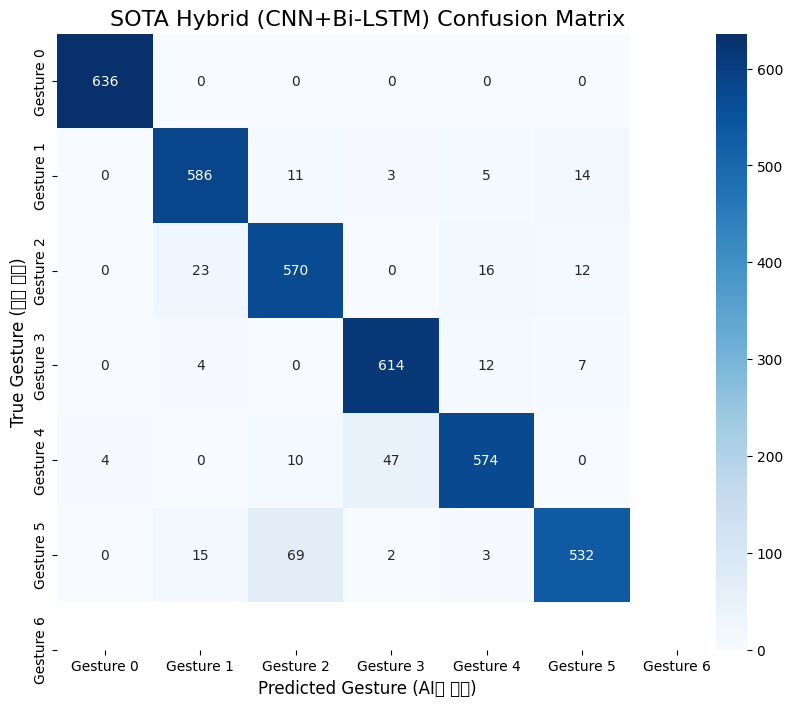

Text(0.5, 0, 'Predicted Gesture')

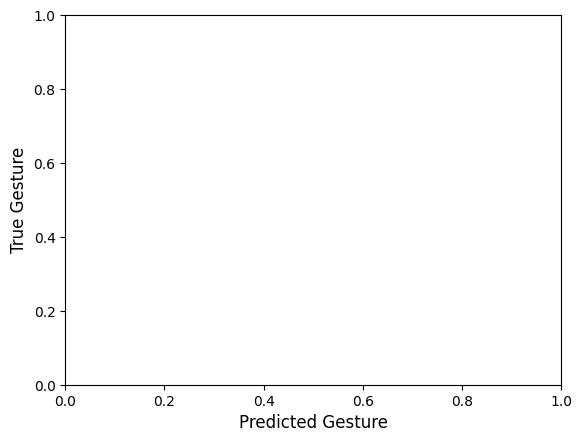

In [9]:
# --- 주피터 셀 6 (SOTA 완전판): 최종 평가 리포트 및 혼동 행렬 시각화 ---
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import torch

print("📊 SOTA 하이브리드 최적 가중치 로드 및 최종 평가 준비 중...")

# 1. 방금 훈련시킨 '하이브리드 모델'로 뼈대 준비
best_model = HybridEMGNet(num_classes=7).cuda()

# 2. SOTA 훈련에서 저장된 새로운 가중치 파일 불러오기
best_model.load_state_dict(torch.load('best_sota_hybrid_emg.pth'))
best_model.eval()

all_preds = []
all_labels = []

# 3. 검증 데이터(생판 처음 보는 6명)로 최종 예측 수행
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.cuda(), labels.cuda()
        outputs = best_model(inputs)
        _, predicted = outputs.max(1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 4. 평가 리포트 텍스트 출력
print("\n📝 [SOTA 분류 성능 상세 리포트]")
print(classification_report(all_labels, all_preds, digits=4))

# 5. 혼동 행렬(Confusion Matrix) 예쁘게 그리기
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f'Gesture {i}' for i in range(7)],
            yticklabels=[f'Gesture {i}' for i in range(7)])

# 그래프 제목도 멋지게 변경
plt.title('SOTA Hybrid (CNN+Bi-LSTM) Confusion Matrix', fontsize=16)
plt.ylabel('True Gesture (실제 정답)', fontsize=12)
plt.xlabel('Predicted Gesture (AI의 예측)', fontsize=12)
plt.show()

# 기존 코드의 이 부분 찾기
plt.ylabel('True Gesture (실제 정답)', fontsize=12)
plt.xlabel('Predicted Gesture (AI의 예측)', fontsize=12)

# 아래와 같이 한글을 지우고 영어로만 수정!
plt.ylabel('True Gesture', fontsize=12)
plt.xlabel('Predicted Gesture', fontsize=12)